In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


PROBLEM STATEMENT


Telecommunication companies face significant revenue loss when customers discontinue their services. Identifying customers who are likely to churn before they leave enables the company to take proactive actions such as personalized offers, improved customer support, and retention campaigns.

The objective of this project is to analyze customer behavior and develop a machine learning classification model to predict whether a customer is likely to churn based on demographic information, account details, subscribed services, contract type, billing method, and payment-related features.

The project also aims to identify the key factors driving customer churn, evaluate multiple machine learning models using appropriate performance metrics, and provide actionable business insights to help improve customer retention and reduce revenue loss.

In [2]:
pd.set_option("display.max_columns", 500)

In [3]:
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# checking the null values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
# cheching the dupicates
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns = df.columns.str.strip()

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce")

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
df.tenure.unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39])

In [15]:
df[df["MonthlyCharges"] < 0].value_counts()

Series([], Name: count, dtype: int64)

In [16]:
df[df["TotalCharges"] < 0].value_counts()

Series([], Name: count, dtype: int64)

In [17]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [18]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [19]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [ ]:
# Mapping the churn Values to 1 and 0 for prediction

df["Churn"] = df["Churn"].map({"Yes" : 1, "No" : 0})

In [22]:
df["Churn"].unique()

array([0, 1])

In [ ]:
# Churn Analysis

df["Churn"].value_counts(normalize=True)

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

<Axes: xlabel='Churn', ylabel='count'>

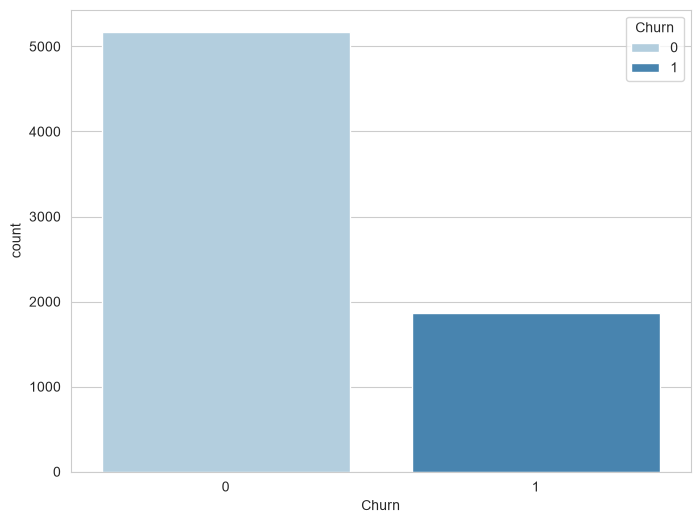

In [ ]:
plt.figure(figsize = (8,6))

sns.countplot(data = df, x = "Churn", hue ="Churn", palette = "Blues")
plt.title("Churn Analysis")
plt.show()

EDA

<Axes: xlabel='SeniorCitizen', ylabel='count'>

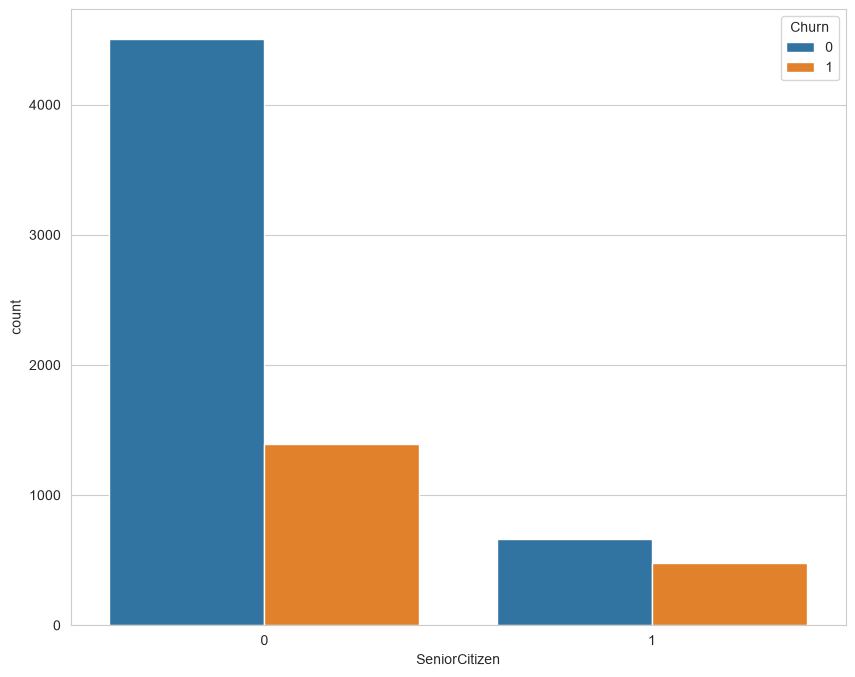

In [ ]:
plt.figure(figsize=(10,8))

sns.countplot(data = df, x="SeniorCitizen", hue="Churn")
plt.title("Senior Citizens Vs Churn Analysis")
plt.show()

In [26]:
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index")

Churn,0,1
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


Senior Citizens tends to churn more may be due to Lower adoption of complex services, poor customer support experience. This relationship may be influenced by factors such as contract type, pricing, service usage, and payment behavior, so further multivariate analysis is needed to identify the underlying drivers.

<Axes: xlabel='gender', ylabel='count'>

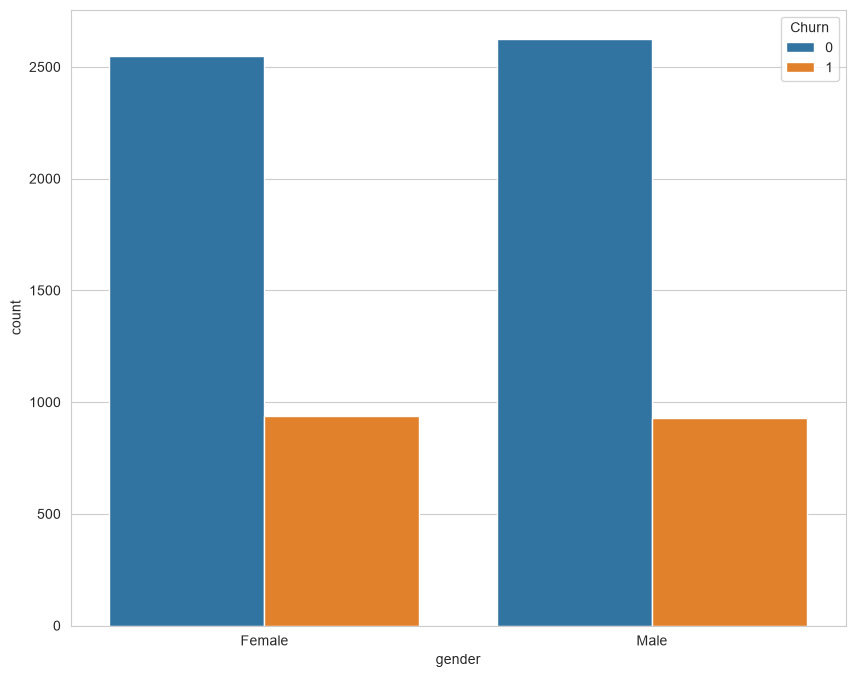

In [ ]:
# Gender-Churn Analysis

plt.figure(figsize=(10,8))

sns.countplot(data = df, x="gender", hue="Churn")
plt.title("Gender Vs Churn Analysis")
plt.show()

In [28]:
pd.crosstab(df["gender"], df["Churn"], normalize="index")

Churn,0,1
gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603


In [29]:
pd.crosstab(df["Partner"], df["Churn"], normalize="index")

Churn,0,1
Partner,,
No,0.670420,0.329580
Yes,0.803351,0.196649


Bechlors churn more

In [30]:
df.tenure.unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39])

In [31]:
tenure_df = df.groupby("tenure")["Churn"].sum().reset_index()
tenure_df.sort_values("Churn", ascending = False)

,tenure,Churn
1,1,380
2,2,123
3,3,94
4,4,83
5,5,64
...,...,...
60,60,6
62,62,5
64,64,4
63,63,4


<Axes: xlabel='tenure', ylabel='Churn'>

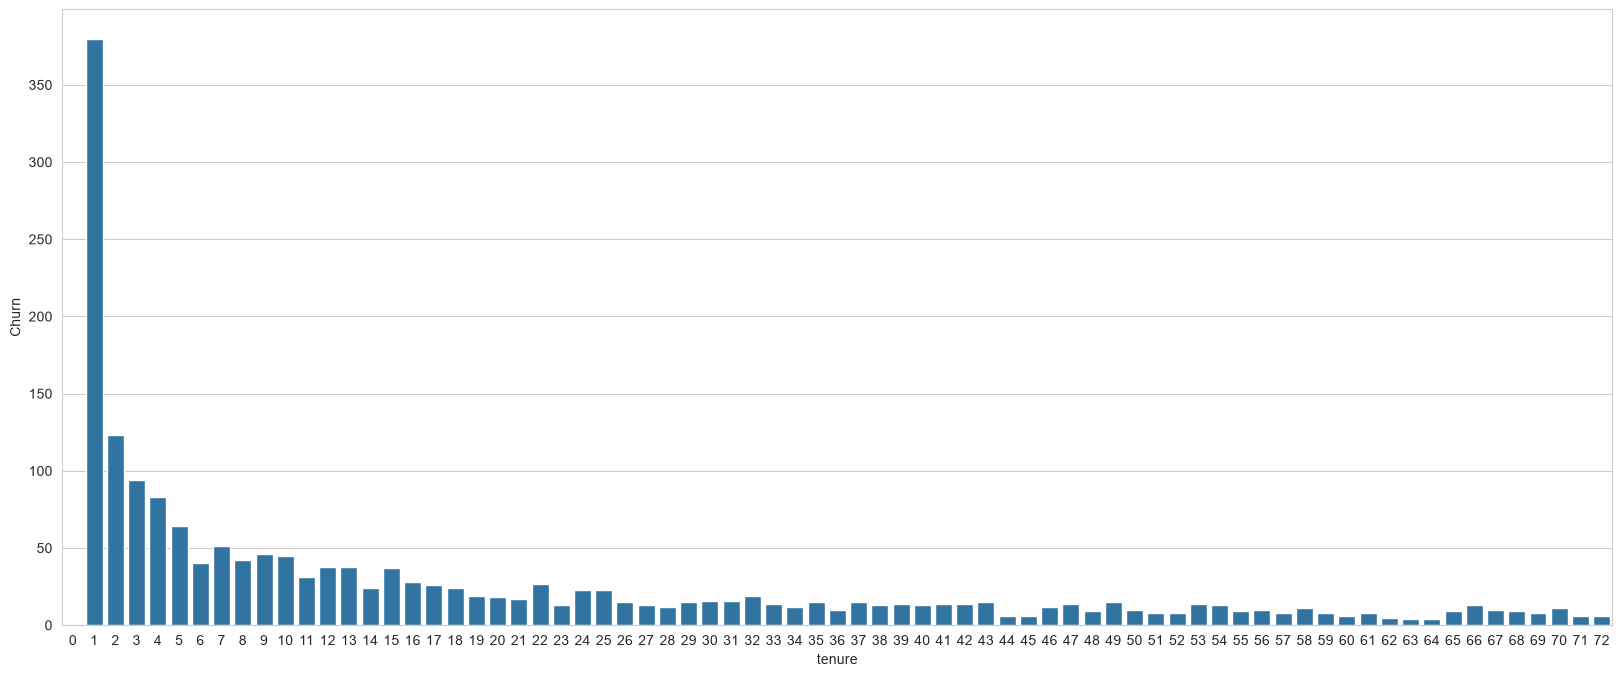

In [32]:
# Based On Tenure
plt.figure(figsize=(20,8))
sns.barplot(data=tenure_df, x = "tenure", y="Churn")

As tenure increases, Custumers stay because trust and satisfaction builds over time. 

Changing to another operator is a big hassle because of service familiarity.

Customer churn shows an inverse relationship with tenure, indicating that newer customers are more likely to leave, while long-term customers demonstrate greater loyalty and retention. This highlights the importance of improving onboarding and engagement during the early stages of the customer lifecycle.


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [34]:
# Contract Basis
px.histogram(df, x="Contract", color="Churn")

In [35]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,0,1
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


Month to month Contracts churn more. As the Contract period increases, Customers stay for longer periods.

In [36]:
#Internet Service
px.histogram(df, x="InternetService", color="Churn")

In [37]:
pd.crosstab(df["InternetService"], df["Churn"], normalize ="index")

Churn,0,1
InternetService,,
DSL,0.810409,0.189591
Fiber optic,0.581072,0.418928
No,0.925950,0.074050


In [38]:
pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize ="index")

Churn,0,1
OnlineSecurity,,
No,0.582333,0.417667
No internet service,0.925950,0.074050
Yes,0.853888,0.146112


In [39]:
pd.crosstab(df["TechSupport"], df["Churn"], normalize ="index")

Churn,0,1
TechSupport,,
No,0.583645,0.416355
No internet service,0.925950,0.074050
Yes,0.848337,0.151663


In [40]:
pd.crosstab(df["OnlineBackup"], df["Churn"], normalize ="index")

Churn,0,1
OnlineBackup,,
No,0.600712,0.399288
No internet service,0.925950,0.074050
Yes,0.784685,0.215315


In [41]:
pd.crosstab(df["DeviceProtection"], df["Churn"], normalize ="index")

Churn,0,1
DeviceProtection,,
No,0.608724,0.391276
No internet service,0.925950,0.074050
Yes,0.774979,0.225021


By looking at the parameters like Tech support, Device Protection, Online Security and Online Backup, we can make a inference that people who are ditally not sound or who are not invested in other services CHURN more

In [42]:
#Multiple Lines has made no major difference
px.histogram(df, x="MultipleLines", color="Churn")

<Axes: xlabel='PaymentMethod', ylabel='count'>

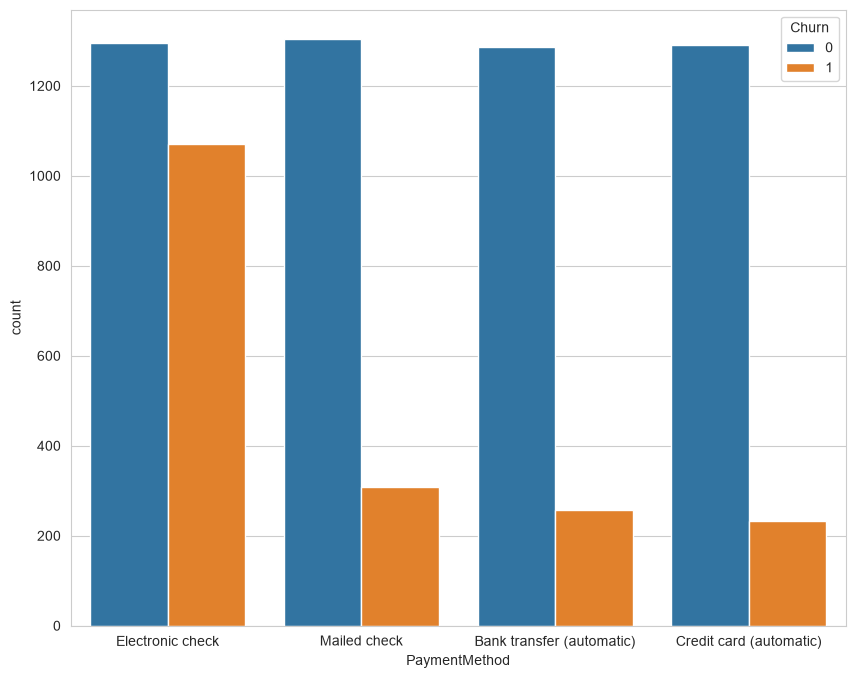

In [ ]:
plt.figure(figsize=(10,8))
sns.countplot(data = df, x="PaymentMethod", hue="Churn")
plt.title("Payment Method Vs Churn")
plt.show()

In [44]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize ="index")

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


Electronic Checks churn at highest rate, may be due to they are those customers who only need the services for one time only.

In [45]:
df["MonthlyCharges"].nunique()

1585

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

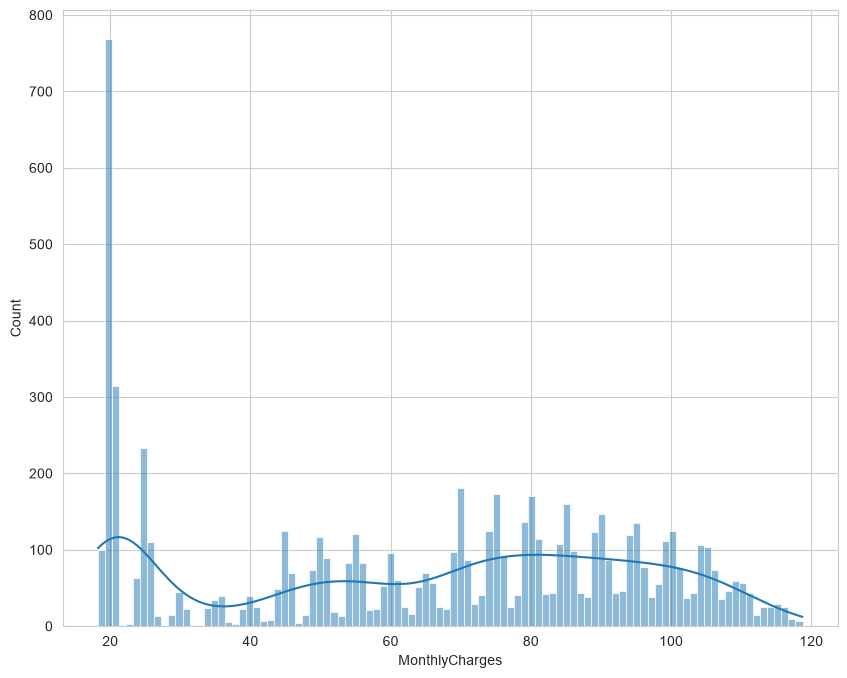

In [ ]:
plt.figure(figsize=(10,8))
sns.histplot(data=df, x="MonthlyCharges", bins=100, kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()

Some Feature Engineering Steps

In [47]:
df["tenureperiod"] = pd.cut(df["tenure"], bins=[0,12,24,36,48,72], labels=["0-1 Year", "1-2 Year", "2-3 Year", "3-4 Year", "4+Year"])
df["AverageMonthlyCharges"] = df["TotalCharges"] / df["tenure"]

In [48]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenureperiod,AverageMonthlyCharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1 Year,29.850000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2-3 Year,55.573529
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1 Year,54.075000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3-4 Year,40.905556
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1 Year,75.825000


<Axes: xlabel='tenureperiod', ylabel='Count'>

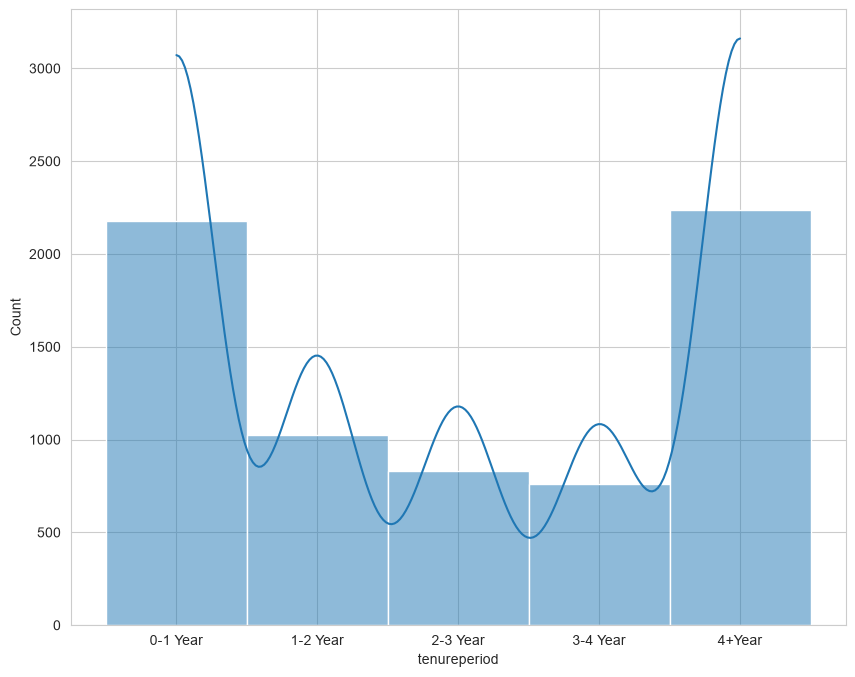

In [49]:
plt.figure(figsize=(10,8))
sns.histplot(data=df, x="tenureperiod", bins=4, kde=True)

In [50]:
px.histogram(df, x="tenureperiod", color="Churn")

Less than a year customers Churn more

In [51]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'tenureperiod',
 'AverageMonthlyCharges']

In [ ]:
# Exporting for EDA analysis in SQL

df.to_csv("Churn_Cleaned Data.csv")

In [53]:
features =  ['SeniorCitizen',
 'tenure',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'Contract',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 ]

In [54]:
X= df[features].copy()

In [55]:
X.head()

,SeniorCitizen,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaymentMethod,MonthlyCharges,TotalCharges
0,0,1,DSL,No,Yes,No,No,Month-to-month,Electronic check,29.85,29.85
1,0,34,DSL,Yes,No,Yes,No,One year,Mailed check,56.95,1889.50
2,0,2,DSL,Yes,Yes,No,No,Month-to-month,Mailed check,53.85,108.15
3,0,45,DSL,Yes,No,Yes,Yes,One year,Bank transfer (automatic),42.30,1840.75
4,0,2,Fiber optic,No,No,No,No,Month-to-month,Electronic check,70.70,151.65


In [56]:
y = df["Churn"]

In [57]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     7043 non-null   int64  
 1   tenure            7043 non-null   int64  
 2   InternetService   7043 non-null   str    
 3   OnlineSecurity    7043 non-null   str    
 4   OnlineBackup      7043 non-null   str    
 5   DeviceProtection  7043 non-null   str    
 6   TechSupport       7043 non-null   str    
 7   Contract          7043 non-null   str    
 8   PaymentMethod     7043 non-null   str    
 9   MonthlyCharges    7043 non-null   float64
 10  TotalCharges      7043 non-null   float64
dtypes: float64(2), int64(2), str(7)
memory usage: 1019.2 KB


In [58]:
numerical_features = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

In [59]:
corr = X[numerical_features].corr()
px.imshow(df.corr(numeric_only = True), color_continuous_scale="Blues", text_auto = "0.2f")

In [60]:
cat_features = [x for x in features
                if x not in numerical_features]

In [61]:
cat_features

['InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'Contract',
 'PaymentMethod']

In [62]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [63]:
from sklearn.model_selection import train_test_split

In [64]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    average_precision_score
)

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [66]:
#Preprocessing the numerical and categorical data
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), numerical_features), ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cat_features)])

LOGISTIC MODEL

In [67]:
#Traing the Logistic model

logistic_model = Pipeline(steps=[("preprocessor", preprocessor), ("model", LogisticRegression(max_iter=1000, random_state=42))])

In [68]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['SeniorCitizen','tenure','InternetService',...,'PaymentMethod', 'MonthlyCharges','TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [69]:
logistic_preds = logistic_model.predict(X_test)
logistic_probs = logistic_model.predict_proba(X_test)[:,1]

In [70]:
print(f"Accuracy : {accuracy_score(y_test, logistic_preds)},\nPrecision Score : {precision_score(y_test, logistic_preds)},\nRecall Score : {recall_score(y_test, logistic_preds)},\nAverage Precision Score : {average_precision_score(y_test, logistic_probs)},\nF1 Score : {f1_score(y_test, logistic_preds)},\nROC_AUC_Score : {roc_auc_score(y_test, logistic_probs)}")

Accuracy : 0.7978421351504826,
Precision Score : 0.6377171215880894,
Recall Score : 0.550321199143469,
Average Precision Score : 0.6352816264460531,
F1 Score : 0.5908045977011495,
ROC_AUC_Score : 0.8440810659641435


In [ ]:
# Logistic Classification Report
print(f"Logistic Classification Report : \n {classification_report(y_test, logistic_preds)}")

Logistic Classification Report : 
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1294
           1       0.64      0.55      0.59       467

    accuracy                           0.80      1761
   macro avg       0.74      0.72      0.73      1761
weighted avg       0.79      0.80      0.79      1761



Logistic Confusion Matrix :
 [[1148  146]
 [ 210  257]]


Text(0.5, 1.0, 'Logistic Confusion Matrix')

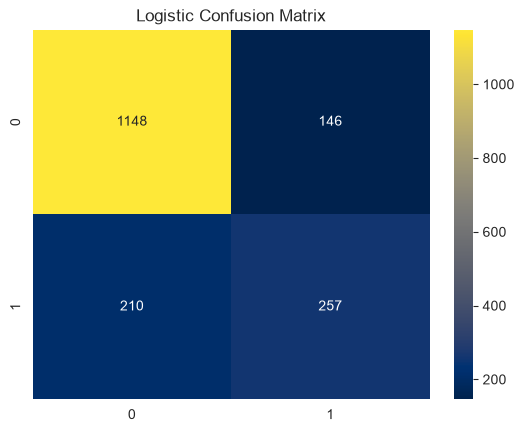

In [ ]:
#Logistic Confusion Matrix and Heatmap 

print("Logistic Confusion Matrix :\n", confusion_matrix(y_test, logistic_preds))
sns.heatmap(confusion_matrix(y_test, logistic_preds), annot=True, cmap="cividis", fmt=".0f")
plt.title("Logistic Confusion Matrix")

DECISION TREE CLASSIFIER MODEL

In [73]:
#Training the Decision Tree Model

In [74]:
dt_model = Pipeline(steps=[("preprocessor", preprocessor), ("model", DecisionTreeClassifier(random_state=42, max_depth=10, criterion="gini"))])

In [75]:
dt_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['SeniorCitizen','tenure','InternetService',...,'PaymentMethod', 'MonthlyCharges','TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [76]:
dt_preds = dt_model.predict(X_test)
dt_probs = dt_model.predict_proba(X_test)[:,1]

In [77]:
print(f"Accuracy : {accuracy_score(y_test, dt_preds)},\nPrecision Score : {precision_score(y_test, dt_preds)},\nRecall Score : {recall_score(y_test, dt_preds)},\nAverage Precision Score : {average_precision_score(y_test, dt_probs)},\nF1 Score : {f1_score(y_test, dt_preds)},\nROC_AUC_Score : {roc_auc_score(y_test, dt_probs)}")

Accuracy : 0.7734241908006815,
Precision Score : 0.5790697674418605,
Recall Score : 0.5331905781584583,
Average Precision Score : 0.5008280019647142,
F1 Score : 0.5551839464882943,
ROC_AUC_Score : 0.767555080440445


In [ ]:
# Decision Tree Classification Report
print(f"Classification Decision Tree Report : \n {classification_report(y_test, dt_preds)}")

Classification Decision Tree Report : 
               precision    recall  f1-score   support

           0       0.84      0.86      0.85      1294
           1       0.58      0.53      0.56       467

    accuracy                           0.77      1761
   macro avg       0.71      0.70      0.70      1761
weighted avg       0.77      0.77      0.77      1761



DT Confusion_matrix
 [[1113  181]
 [ 218  249]]


Text(0.5, 1.0, 'Decision Tree Confusion Matrix')

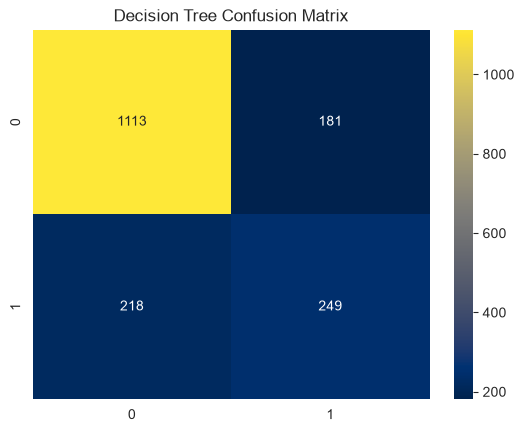

In [ ]:
#Decision Tree Confusion Matrix

print("DT Confusion_matrix\n", confusion_matrix(y_test, dt_preds))
sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, cmap="cividis", fmt=".0f")
plt.title("Decision Tree Confusion Matrix")

RANDOM FOREST CLASSIFIER

In [80]:
# Training the Random Forest Model

rf_model = Pipeline(steps = [("preprocessor", preprocessor), ("model", RandomForestClassifier(n_estimators=300, max_depth = 10, n_jobs=-1, random_state=42))])

In [81]:
rf_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['SeniorCitizen','tenure','InternetService',...,'PaymentMethod', 'MonthlyCharges','TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [82]:
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:,1]

In [83]:
print(f"Accuracy : {accuracy_score(y_test, rf_preds)},\nPrecision Score : {precision_score(y_test, rf_preds)},\nRecall Score : {recall_score(y_test, rf_preds)},\nAverage Precision Score : {average_precision_score(y_test, rf_probs)},\nF1 Score : {f1_score(y_test, rf_preds)},\nROC_AUC_Score : {roc_auc_score(y_test, rf_probs)}")

Accuracy : 0.7950028392958546,
Precision Score : 0.6432432432432432,
Recall Score : 0.5096359743040685,
Average Precision Score : 0.6446383999254051,
F1 Score : 0.5686977299880526,
ROC_AUC_Score : 0.8349191954962619


In [84]:
print(f"Classification Random Forest Report : \n {classification_report(y_test, rf_preds)}")

Classification Random Forest Report : 
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1294
           1       0.64      0.51      0.57       467

    accuracy                           0.80      1761
   macro avg       0.74      0.70      0.72      1761
weighted avg       0.78      0.80      0.79      1761



Random Forest Confusion_matrix
 [[1162  132]
 [ 229  238]]


Text(0.5, 1.0, 'RandomForest Confusion Matrix')

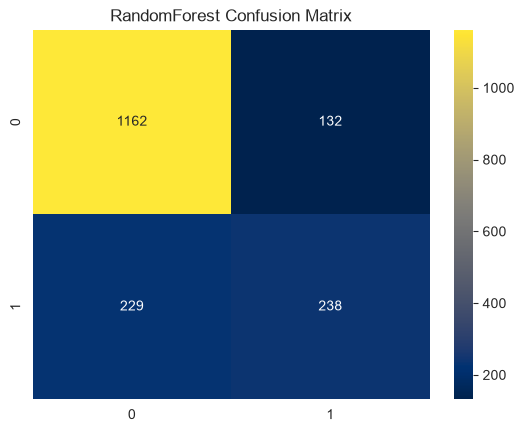

In [85]:
print("Random Forest Confusion_matrix\n", confusion_matrix(y_test, rf_preds))

sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, cmap="cividis", fmt=".0f")
plt.title("RandomForest Confusion Matrix")

In [86]:
#Training the Extra trees model

from sklearn.ensemble import ExtraTreesClassifier


In [87]:
xt_model = Pipeline(steps = [("preprocessor", preprocessor), ("model", ExtraTreesClassifier(n_estimators = 100, max_depth = 10, n_jobs = -1, random_state=42))])

In [88]:
xt_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['SeniorCitizen','tenure','InternetService',...,'PaymentMethod', 'MonthlyCharges','TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [89]:
xt_preds = xt_model.predict(X_test)
xt_probs = xt_model.predict_proba(X_test)[:,1]

In [90]:
print(f"Accuracy : {accuracy_score(y_test, xt_preds)},\nPrecision Score : {precision_score(y_test, xt_preds)},\nRecall Score : {recall_score(y_test,xt_preds)},\nAverage Precision Score : {average_precision_score(y_test, xt_probs)},\nF1 Score : {f1_score(y_test, xt_preds)},\nROC_AUC_Score : {roc_auc_score(y_test, xt_probs)}")

Accuracy : 0.7915956842703009,
Precision Score : 0.6275510204081632,
Recall Score : 0.5267665952890792,
Average Precision Score : 0.6295682248643779,
F1 Score : 0.5727590221187427,
ROC_AUC_Score : 0.8326231428864567


In [91]:
print(f"Classification Extra Trees Report : \n {classification_report(y_test, xt_preds)}")

Classification Extra Trees Report : 
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1294
           1       0.63      0.53      0.57       467

    accuracy                           0.79      1761
   macro avg       0.73      0.71      0.72      1761
weighted avg       0.78      0.79      0.79      1761



Extra Trees Confusion_matrix
 [[1148  146]
 [ 221  246]]


Text(0.5, 1.0, 'Extra Trees Confusion Matrix')

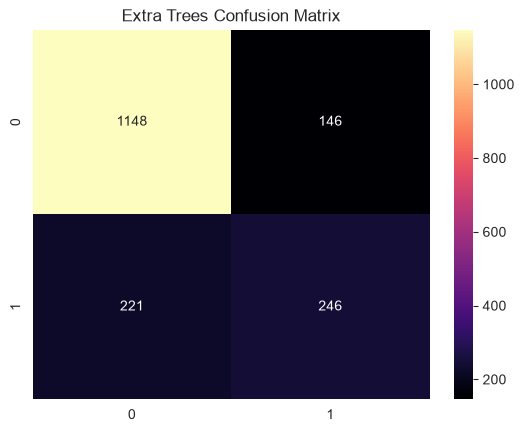

In [92]:
print("Extra Trees Confusion_matrix\n", confusion_matrix(y_test, xt_preds))
sns.heatmap(confusion_matrix(y_test, xt_preds), annot=True, cmap="magma", fmt=".0f")
plt.title("Extra Trees Confusion Matrix")

In [93]:
#Training the Gradient Boost Model

In [94]:
gb_model = Pipeline(
    steps=[("preprocessor", preprocessor),("model",GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=10,
                random_state=42
            )
        )
    ]
)

In [95]:
gb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['SeniorCitizen','tenure','InternetService',...,'PaymentMethod', 'MonthlyCharges','TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [96]:
gb_preds = gb_model.predict(X_test)
gb_probs = gb_model.predict_proba(X_test)[:,1]

In [97]:
print(f"Classification GB Report : \n {classification_report(y_test, gb_preds)}")

Classification GB Report : 
               precision    recall  f1-score   support

           0       0.83      0.88      0.85      1294
           1       0.59      0.51      0.55       467

    accuracy                           0.78      1761
   macro avg       0.71      0.69      0.70      1761
weighted avg       0.77      0.78      0.77      1761



GB Confusion_Matrix
 [[1133  161]
 [ 231  236]]


Text(0.5, 1.0, 'GB Confusion Matrix')

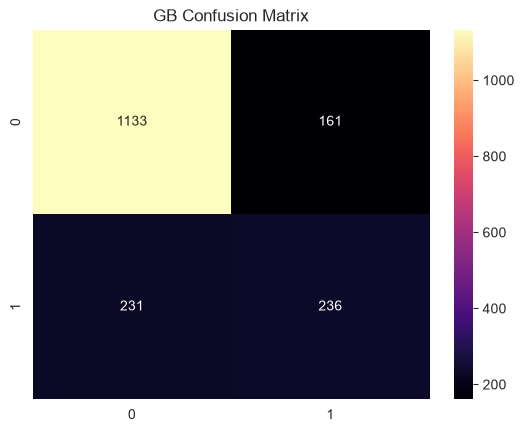

In [98]:
print("GB Confusion_Matrix\n", confusion_matrix(y_test, gb_preds))
sns.heatmap(confusion_matrix(y_test, gb_preds), annot=True, cmap="magma", fmt=".0f")
plt.title("GB Confusion Matrix")

In [99]:
from sklearn.naive_bayes import GaussianNB


nb_model = Pipeline([("preprocessor", preprocessor), ("model", GaussianNB())])


nb_model.fit(X_train,y_train)


nb_preds = nb_model.predict(X_test)
nb_probs = nb_model.predict_proba(X_test)[:,1]

In [100]:
print(f"Accuracy : {accuracy_score(y_test, nb_preds)},\nPrecision Score : {precision_score(y_test, nb_preds)},\nRecall Score : {recall_score(y_test,nb_preds)},\nAverage Precision Score : {average_precision_score(y_test, nb_probs)},\nF1 Score : {f1_score(y_test, nb_preds)},\nROC_AUC_Score : {roc_auc_score(y_test, nb_probs)}")

Accuracy : 0.706984667802385,
Precision Score : 0.47023086269744835,
Recall Score : 0.828693790149893,
Average Precision Score : 0.5947542531667999,
F1 Score : 0.6,
ROC_AUC_Score : 0.8160816352197096


In [101]:
print(f"Classification NB Report : \n {classification_report(y_test, nb_preds)}")

Classification NB Report : 
               precision    recall  f1-score   support

           0       0.91      0.66      0.77      1294
           1       0.47      0.83      0.60       467

    accuracy                           0.71      1761
   macro avg       0.69      0.75      0.68      1761
weighted avg       0.80      0.71      0.72      1761



NB Confusion_Matrix
 [[858 436]
 [ 80 387]]


Text(0.5, 1.0, 'NB Confusion Matrix')

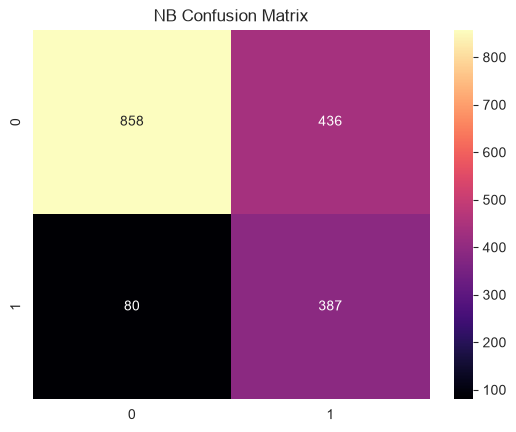

In [102]:
print("NB Confusion_Matrix\n", confusion_matrix(y_test, nb_preds))
sns.heatmap(confusion_matrix(y_test, nb_preds), annot=True, cmap="magma", fmt=".0f")
plt.title("NB Confusion Matrix")

In [103]:
def evaluate_model(model, test, pred, prob):

    accuracy = accuracy_score(test, pred)
    recall = recall_score(test, pred)
    precision = precision_score(test, pred)
    f1 = f1_score(test, pred)
    pr_auc = average_precision_score(test,prob)
    roc_auc = roc_auc_score(test, prob)

    return({
        "Model" : model,
        "Accuracy" : accuracy,
        "Recall" : recall,
        "Precision" : precision,
        "F1 Score" : f1,
        "PR_AUC" : pr_auc,
        "ROC_AUC" : roc_auc
    })


In [104]:
Score_Results = []

In [105]:
Score_Results.append(evaluate_model("Logistic Regression", y_test, logistic_preds, logistic_probs))
Score_Results.append(evaluate_model("Decision Tree Classifier", y_test, dt_preds, dt_probs))
Score_Results.append(evaluate_model("Random Forest Classifier", y_test, rf_preds, rf_probs))
Score_Results.append(evaluate_model("Extra Trees Model", y_test, xt_preds, xt_probs))
Score_Results.append(evaluate_model("Gradient Boost Classifier", y_test, gb_preds, gb_probs))
Score_Results.append(evaluate_model("Gaussian Naive Beyes", y_test, nb_preds, nb_probs))

In [106]:
Score_Results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.7978421351504826,
  'Recall': 0.550321199143469,
  'Precision': 0.6377171215880894,
  'F1 Score': 0.5908045977011495,
  'PR_AUC': 0.6352816264460531,
  'ROC_AUC': 0.8440810659641435},
 {'Model': 'Decision Tree Classifier',
  'Accuracy': 0.7734241908006815,
  'Recall': 0.5331905781584583,
  'Precision': 0.5790697674418605,
  'F1 Score': 0.5551839464882943,
  'PR_AUC': 0.5008280019647142,
  'ROC_AUC': 0.767555080440445},
 {'Model': 'Random Forest Classifier',
  'Accuracy': 0.7950028392958546,
  'Recall': 0.5096359743040685,
  'Precision': 0.6432432432432432,
  'F1 Score': 0.5686977299880526,
  'PR_AUC': 0.6446383999254051,
  'ROC_AUC': 0.8349191954962619},
 {'Model': 'Extra Trees Model',
  'Accuracy': 0.7915956842703009,
  'Recall': 0.5267665952890792,
  'Precision': 0.6275510204081632,
  'F1 Score': 0.5727590221187427,
  'PR_AUC': 0.6295682248643779,
  'ROC_AUC': 0.8326231428864567},
 {'Model': 'Gradient Boost Classifier',
  'Accuracy': 

In [107]:
Results_df = pd.DataFrame(Score_Results)
Results_df

,Model,Accuracy,Recall,Precision,F1 Score,PR_AUC,ROC_AUC
0,Logistic Regression,0.797842,0.550321,0.637717,0.590805,0.635282,0.844081
1,Decision Tree Classifier,0.773424,0.533191,0.579070,0.555184,0.500828,0.767555
2,Random Forest Classifier,0.795003,0.509636,0.643243,0.568698,0.644638,0.834919
3,Extra Trees Model,0.791596,0.526767,0.627551,0.572759,0.629568,0.832623
4,Gradient Boost Classifier,0.777399,0.505353,0.594458,0.546296,0.612407,0.818674
5,Gaussian Naive Beyes,0.706985,0.828694,0.470231,0.600000,0.594754,0.816082


In [108]:
px.bar(Results_df, x="Model", y="Accuracy", color = "Accuracy", color_continuous_scale="Greens")

In [109]:
px.bar(Results_df, x="Model", y="Recall", color = "Recall", color_continuous_scale="Blues")

In [110]:
px.bar(Results_df, x="Model", y="Precision", color = "Precision", color_continuous_scale="Blues")

In [111]:
px.bar(Results_df, x="Model", y="F1 Score", color = "F1 Score", color_continuous_scale="viridis")

In [112]:
models = {
    "Logistic Regression" : logistic_probs,
    "Gradient Boosting" : gb_probs,
    "Decision Tree Model" : dt_probs,
    "Random Forest Model" : rf_probs,
    "Extra Trees Model" : xt_probs,
    "NB Model" : nb_probs
}

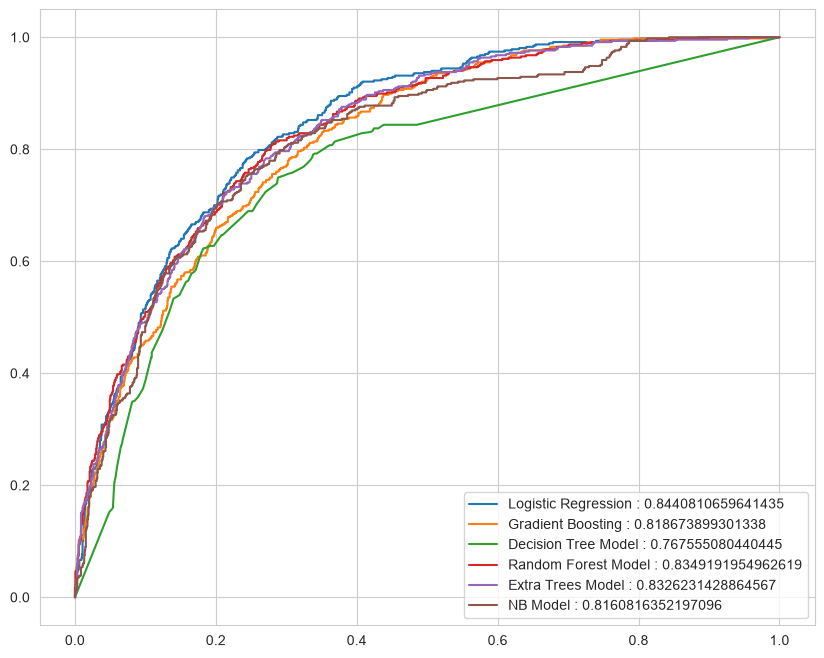

In [113]:
plt.figure(figsize=(10,8))

for model, prob in models.items():

    fpr, tpr, threshold = roc_curve(y_test, prob)

    roc_auc = roc_auc_score(y_test, prob)

    plt.plot(fpr, tpr, label = f"{model} : {roc_auc}")
    plt.legend()

Since the models more or less produced almost similar results so now we will try to tune the hyperparameters if they helps.

In [114]:
from sklearn.model_selection import GridSearchCV

In [115]:
# Applying to Random Forest

In [116]:
rf_model_tuned = Pipeline(steps = [("preprocessor", preprocessor), ("model", RandomForestClassifier(n_jobs = -1, random_state=42))])

rf_param_grid = {
    "model__n_estimators": [100, 200, 300,400,500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(estimator=rf_model_tuned, param_grid = rf_param_grid, cv=5, scoring="roc_auc", n_jobs=-1, verbose=1)

In [117]:
grid_rf.fit(X_train,y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple m

In [118]:
print("RF Best Parameters:")
print(grid_rf.best_params_)

print("RF Best CV ROC-AUC:")
print(grid_rf.best_score_)

RF Best Parameters:
{'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 500}
RF Best CV ROC-AUC:
0.8414047783924443


In [119]:
best_rf = grid_rf.best_estimator_

In [120]:
best_rf_preds = best_rf.predict(X_test)

In [121]:
best_rf_probs = best_rf.predict_proba(X_test)[:, 1]

In [122]:
#Fine Tuning the Extra Trees Model

xt_model_tuned = Pipeline(steps = [("preprocessor", preprocessor), ("model", ExtraTreesClassifier(n_jobs = -1, random_state=42))])

xt_param_grid = {
    "model__n_estimators": [100, 200, 300, 40, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

grid_xt = GridSearchCV(
    estimator=xt_model_tuned,
    param_grid=xt_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [123]:
grid_xt.fit(X_train, y_train)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple m

In [124]:
print("XT Best Parameters:")
print(grid_xt.best_params_)

print("XT Best CV ROC-AUC:")
print(grid_xt.best_score_)

XT Best Parameters:
{'model__max_depth': 10, 'model__max_features': 'log2', 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 200}
XT Best CV ROC-AUC:
0.8355878486653493


In [125]:
best_xt = grid_xt.best_estimator_

best_xt_preds = best_xt.predict(X_test)

best_xt_probs = best_xt.predict_proba(X_test)[:, 1]

In [126]:
#Fine tuning the Gradient Boost

In [127]:
gb_model_tuned = Pipeline(steps = [("preprocessor", preprocessor), ("model", GradientBoostingClassifier(random_state=42))])

gb_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.8, 1.0]
}

grid_gb = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

In [128]:
grid_gb.fit(X_train, y_train)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple met

In [129]:
print("Best Parameters:")
print(grid_gb.best_params_)

print("Best CV ROC-AUC:")
print(grid_gb.best_score_)

Best Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV ROC-AUC:
0.845837163716791


In [130]:
best_gb = grid_gb.best_estimator_

best_gb_preds = best_gb.predict(X_test)

best_gb_probs = best_gb.predict_proba(X_test)[:, 1]

In [131]:
def re_evaluate_model(model, test, pred, prob):

    accuracy = accuracy_score(test, pred)
    recall = recall_score(test, pred)
    precision = precision_score(test, pred)
    f1 = f1_score(test, pred)
    pr_auc = average_precision_score(test,prob)
    roc_auc = roc_auc_score(test, prob)

    return({
        "Model" : model,
        "Accuracy" : accuracy,
        "Recall" : recall,
        "Precision" : precision,
        "F1 Score" : f1,
        "PR_AUC" : pr_auc,
        "ROC_AUC" : roc_auc
    })

In [132]:
Revaluated_Results = []

In [133]:
Revaluated_Results.append(evaluate_model("Logistic Regression", y_test, logistic_preds, logistic_probs))
Revaluated_Results.append(evaluate_model("Random Forest Classifier", y_test, best_rf_preds, best_rf_probs))
Revaluated_Results.append(evaluate_model("Extra Trees Model", y_test, best_xt_preds, best_xt_probs))
Revaluated_Results.append(evaluate_model("Gradient Boost Classifier", y_test, best_gb_preds, best_gb_probs))
Revaluated_Results.append(evaluate_model("Gaussian Naive Beyes", y_test, nb_preds, nb_probs))

In [134]:
Revaluated_Results_df = pd.DataFrame(Revaluated_Results)

In [135]:
Revaluated_Results_df

,Model,Accuracy,Recall,Precision,F1 Score,PR_AUC,ROC_AUC
0,Logistic Regression,0.797842,0.550321,0.637717,0.590805,0.635282,0.844081
1,Random Forest Classifier,0.795003,0.501071,0.646409,0.564536,0.650722,0.840096
2,Extra Trees Model,0.793299,0.498929,0.641873,0.561446,0.639936,0.836416
3,Gradient Boost Classifier,0.800114,0.498929,0.663818,0.569682,0.660917,0.846759
4,Gaussian Naive Beyes,0.706985,0.828694,0.470231,0.600000,0.594754,0.816082


Results:

1. Fine Tuned Gradient Model gives the best overall results. So this can be our main model to interpret the data.
2. NB is interesting because its recall is very high. and it can seperate actual churners easily. So if company focuses only on the FNs, then it is the major model.

In [136]:
# Now focusing on the Gradient Boost model by changing its threshhold

thresholds = [0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

threshold_results = []

for threshold in thresholds:

    gb_preds_threshold = (best_gb_probs >= threshold).astype(int)
  
    recall = recall_score(y_test, gb_preds_threshold)
    precision = precision_score(y_test, gb_preds_threshold)
    f1 = f1_score(y_test, gb_preds_threshold)

    threshold_results.append({"threshold" : threshold,
                              "Recall" : recall,
                              "Precision" : precision,
                              "F1" : f1})


In [137]:
threshold_results_df = pd.DataFrame(threshold_results)

In [138]:
threshold_results_df

,threshold,Recall,Precision,F1
0,0.25,0.820128,0.518970,0.635685
1,0.30,0.777302,0.555046,0.647636
2,0.35,0.689507,0.583333,0.631992
3,0.40,0.625268,0.603306,0.614090
4,0.45,0.563169,0.636804,0.597727
5,0.50,0.498929,0.663818,0.569682


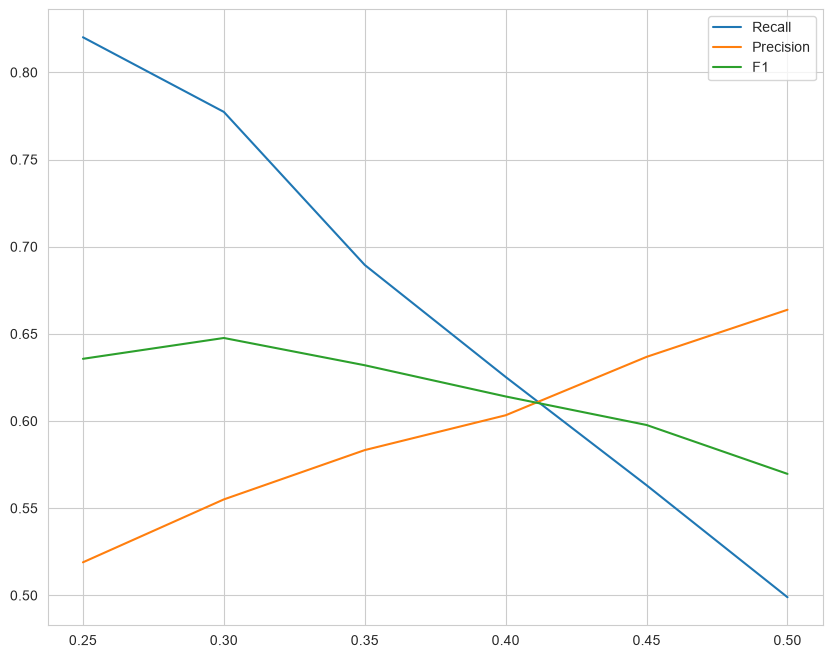

In [139]:
plt.figure(figsize=(10,8))
plt.plot(threshold_results_df["threshold"], threshold_results_df["Recall"], label = f"Recall")
plt.plot(threshold_results_df["threshold"], threshold_results_df["Precision"], label = f"Precision")
plt.plot(threshold_results_df["threshold"], threshold_results_df["F1"], label = "F1")

plt.legend()
plt.show()

In [140]:
# Final Model Selction Gradient Boosting
#Best Parameters:
#{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 100, 'model__subsample': 0.8}

final_model = Pipeline(steps = [("preprocessor", preprocessor), ("model", GradientBoostingClassifier(learning_rate = 0.05, max_depth = 3, min_samples_leaf = 2, min_samples_split = 10, n_estimators = 100, subsample= 0.8))])

In [141]:
final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['SeniorCitizen','tenure','InternetService',...,'PaymentMethod', 'MonthlyCharges','TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [142]:
final_preds = final_model.predict(X_test)
final_probs = final_model.predict_proba(X_test)[:, 1]

In [143]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, final_preds))
print("Precision:", precision_score(y_test, final_preds))
print("Recall   :", recall_score(y_test, final_preds))
print("F1 Score :", f1_score(y_test, final_preds))
print("ROC-AUC  :", roc_auc_score(y_test, final_probs))

Accuracy : 0.7967064168086314
Precision: 0.6579710144927536
Recall   : 0.4860813704496788
F1 Score : 0.5591133004926109
ROC-AUC  : 0.8455828084819079


In [144]:
import joblib

In [145]:
joblib.dump(final_model, "final_model.pkl")

['final_model.pkl']

In [146]:
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [147]:
# Now Checking the prediction

In [148]:
X.columns.tolist()

['SeniorCitizen',
 'tenure',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'Contract',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges']

In [149]:
X.InternetService.unique()

<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

In [150]:
X.PaymentMethod.unique()

<ArrowStringArray>
[         'Electronic check',              'Mailed check',
 'Bank transfer (automatic)',   'Credit card (automatic)']
Length: 4, dtype: str

In [151]:
customer = {
    "SeniorCitizen": 0,
    "tenure": 72,
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "Contract": "Month-to-month",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.50,
    "TotalCharges": 171.00
}

In [152]:
loaded_preprocessor = joblib.load("preprocessor.pkl")

In [153]:
load_model = joblib.load("final_model.pkl")

In [154]:
customer_df = pd.DataFrame([customer])

In [155]:
customer_df

,SeniorCitizen,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaymentMethod,MonthlyCharges,TotalCharges
0,0,72,Fiber optic,No,No,No,No,Month-to-month,Electronic check,85.5,171.0


In [156]:
predict = load_model.predict(customer_df)[0]

In [157]:
probability = load_model.predict_proba(customer_df)[0][1]

In [158]:
print(predict, probability)

0 0.49355910824535065


In [159]:
best_gb_preds


array([0, 0, 0, ..., 0, 0, 0], shape=(1761,))

In [160]:
best_gb_probs

array([0.11419381, 0.07871441, 0.03512547, ..., 0.16405351, 0.33512284,
       0.28229604], shape=(1761,))

In [161]:
X_test

,SeniorCitizen,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaymentMethod,MonthlyCharges,TotalCharges
5909,0,52,Fiber optic,No,Yes,No,No,One year,Mailed check,80.20,4297.60
3670,0,33,No,No internet service,No internet service,No internet service,No internet service,Month-to-month,Bank transfer (automatic),24.25,838.50
6220,0,10,DSL,Yes,Yes,Yes,Yes,Two year,Credit card (automatic),53.70,521.00
5905,0,1,Fiber optic,No,Yes,No,No,Month-to-month,Electronic check,85.00,85.00
6435,0,52,DSL,No,Yes,Yes,Yes,Two year,Mailed check,50.20,2554.00
...,...,...,...,...,...,...,...,...,...,...,...
476,1,35,DSL,No,Yes,No,Yes,Month-to-month,Electronic check,76.05,2747.20
1607,1,13,Fiber optic,No,Yes,No,Yes,Month-to-month,Bank transfer (automatic),89.05,1169.35
6808,0,39,Fiber optic,Yes,No,Yes,No,Two year,Electronic check,100.45,3801.70
2962,0,3,DSL,No,No,No,Yes,Month-to-month,Mailed check,31.00,95.05


In [162]:
X_test["Actual_Churn"] = y_test

In [163]:
X_test["Predicted_Churn"] = best_gb_preds

In [164]:
X_test["Churn_Probability"] = best_gb_probs *100

In [165]:
X_test

,SeniorCitizen,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Predicted_Churn,Churn_Probability
5909,0,52,Fiber optic,No,Yes,No,No,One year,Mailed check,80.20,4297.60,0,0,11.419381
3670,0,33,No,No internet service,No internet service,No internet service,No internet service,Month-to-month,Bank transfer (automatic),24.25,838.50,0,0,7.871441
6220,0,10,DSL,Yes,Yes,Yes,Yes,Two year,Credit card (automatic),53.70,521.00,0,0,3.512547
5905,0,1,Fiber optic,No,Yes,No,No,Month-to-month,Electronic check,85.00,85.00,0,1,81.624239
6435,0,52,DSL,No,Yes,Yes,Yes,Two year,Mailed check,50.20,2554.00,0,0,4.812947
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,1,35,DSL,No,Yes,No,Yes,Month-to-month,Electronic check,76.05,2747.20,0,0,23.835488
1607,1,13,Fiber optic,No,Yes,No,Yes,Month-to-month,Bank transfer (automatic),89.05,1169.35,1,0,47.061971
6808,0,39,Fiber optic,Yes,No,Yes,No,Two year,Electronic check,100.45,3801.70,0,0,16.405351
2962,0,3,DSL,No,No,No,Yes,Month-to-month,Mailed check,31.00,95.05,1,0,33.512284


In [166]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenureperiod,AverageMonthlyCharges
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-1 Year,29.850000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2-3 Year,55.573529
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-1 Year,54.075000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3-4 Year,40.905556
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-1 Year,75.825000


In [167]:
Customer = df["customerID"]

In [168]:
Pred_file = X_test.merge(Customer,left_index=True,
    right_index=True
)

In [169]:
Pred_file


,SeniorCitizen,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Predicted_Churn,Churn_Probability,customerID
5909,0,52,Fiber optic,No,Yes,No,No,One year,Mailed check,80.20,4297.60,0,0,11.419381,5343-SGUBI
3670,0,33,No,No internet service,No internet service,No internet service,No internet service,Month-to-month,Bank transfer (automatic),24.25,838.50,0,0,7.871441,5442-BXVND
6220,0,10,DSL,Yes,Yes,Yes,Yes,Two year,Credit card (automatic),53.70,521.00,0,0,3.512547,6434-TTGJP
5905,0,1,Fiber optic,No,Yes,No,No,Month-to-month,Electronic check,85.00,85.00,0,1,81.624239,1628-BIZYP
6435,0,52,DSL,No,Yes,Yes,Yes,Two year,Mailed check,50.20,2554.00,0,0,4.812947,0298-XACET
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,1,35,DSL,No,Yes,No,Yes,Month-to-month,Electronic check,76.05,2747.20,0,0,23.835488,3780-DDGSE
1607,1,13,Fiber optic,No,Yes,No,Yes,Month-to-month,Bank transfer (automatic),89.05,1169.35,1,0,47.061971,4154-AQUGT
6808,0,39,Fiber optic,Yes,No,Yes,No,Two year,Electronic check,100.45,3801.70,0,0,16.405351,1116-DXXDF
2962,0,3,DSL,No,No,No,Yes,Month-to-month,Mailed check,31.00,95.05,1,0,33.512284,3237-AJGEH


In [170]:
Pred_file.to_csv("Predicted_file.csv")